# Diagnostiquer un modèle : overfitting, biais-variance et régularisation

**Jour 2 — chapitre 01 : Qu'est-ce qu'un bon modèle ? (les pièges du machine learning)**

## Mise en situation

Le notebook précédent a construit et évalué un premier modèle. Un modèle peut pourtant
obtenir un excellent score sur ses données d'entraînement et décevoir sur de nouveaux
passagers. On observe ici concrètement les pièges vus en cours : l'overfitting et son
inverse, l'underfitting, le compromis biais-variance, et la régularisation Ridge (L2) /
Lasso (L1) qui permet de contrôler la complexité d'un modèle.

Comme au notebook précédent, aucune donnée n'est nettoyée : le data cleaning est le sujet
du chapitre suivant.

In [1]:
import pandas as pd
import seaborn as sns

titanic_raw = sns.load_dataset("titanic")
titanic = titanic_raw.rename(columns={
    "survived": "Survived",
    "pclass": "Pclass",
    "sex": "Sex",
    "age": "Age",
    "sibsp": "SibSp",
    "parch": "Parch",
    "fare": "Fare",
})[["Survived", "Pclass", "Sex", "Age", "SibSp", "Parch", "Fare"]].copy()

titanic["Sex_male"] = (titanic["Sex"] == "male").astype(int)

# Les 5 colonnes completes du premier modele (notebook 01)
features = ["Pclass", "Sex_male", "SibSp", "Parch", "Fare"]
# L'arbre de decision recoit aussi Age, qui contient des valeurs manquantes (voir etape 1)
features_arbre = features + ["Age"]

X = titanic[features_arbre]
y = titanic["Survived"]

print("Valeurs manquantes dans Age :", X["Age"].isnull().sum(), "sur", len(X), "passagers")
X.head()

Valeurs manquantes dans Age : 177 sur 891 passagers


,Pclass,Sex_male,SibSp,Parch,Fare,Age
0,3,1,1,0,7.2500,22.0
1,1,0,1,0,71.2833,38.0
2,3,0,0,0,7.9250,26.0
3,1,0,1,0,53.1000,35.0
4,3,1,0,0,8.0500,35.0


## Étape 1 — Overfitting / underfitting : faire varier la profondeur d'un arbre

**Question de réflexion :** que doit-on observer sur le score d'entraînement et le score
de validation quand la profondeur maximale d'un arbre de décision augmente progressivement ?

L'arbre de décision a été présenté au jour 1 : il découpe les données par une suite de
questions (« Sex = male ? », « Pclass ≤ 2 ? »). Plus il est profond, plus il pose de
questions, et plus il peut coller aux données d'entraînement. On lui donne aussi `Age`,
une variable continue de plus sur laquelle multiplier les questions : les arbres de
scikit-learn acceptent les valeurs manquantes sans nettoyage préalable, ce qui n'est pas
le cas de la régression logistique (étape 3).

Chaque profondeur est évaluée en cross-validation à 5 plis sur le jeu d'entraînement, comme
au notebook précédent. Le jeu de test est mis de côté : il ne sert qu'à la fin, pour
vérifier la profondeur retenue.

In [2]:
from sklearn.model_selection import train_test_split, validation_curve
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

profondeurs = list(range(1, 21))

# validation_curve entraine et evalue l'arbre pour chaque profondeur sur les 5 plis de
# cross-validation : on obtient un score d'entrainement et un score de validation par pli.
train_scores_plis, validation_scores_plis = validation_curve(
    DecisionTreeClassifier(random_state=42),
    X_train, y_train,
    param_name="max_depth", param_range=profondeurs, cv=5,
)

train_scores = train_scores_plis.mean(axis=1)
validation_scores = validation_scores_plis.mean(axis=1)
validation_ecarts_types = validation_scores_plis.std(axis=1)

meilleure_profondeur = profondeurs[validation_scores.argmax()]

# Verification finale : la profondeur retenue est reentrainee sur tout le jeu
# d'entrainement, puis evaluee une seule fois sur le jeu de test mis de cote.
arbre_retenu = DecisionTreeClassifier(max_depth=meilleure_profondeur, random_state=42)
arbre_retenu.fit(X_train, y_train)
test_accuracy = accuracy_score(y_test, arbre_retenu.predict(X_test))

print("Meilleure profondeur (score moyen de validation maximal) :", meilleure_profondeur)
print("Score de validation à cette profondeur :", round(validation_scores.max(), 3))
print("Accuracy sur le jeu de test mis de côté :", round(test_accuracy, 3))

Meilleure profondeur (score moyen de validation maximal) : 3
Score de validation à cette profondeur : 0.82
Accuracy sur le jeu de test mis de côté : 0.799


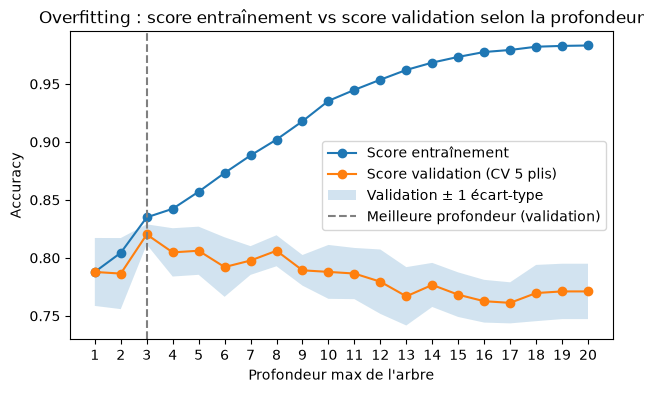

In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(profondeurs, train_scores, marker="o", label="Score entraînement")
ax.plot(profondeurs, validation_scores, marker="o", label="Score validation (CV 5 plis)")
ax.fill_between(
    profondeurs,
    validation_scores - validation_ecarts_types,
    validation_scores + validation_ecarts_types,
    alpha=0.2, label="Validation ± 1 écart-type",
)
ax.axvline(meilleure_profondeur, color="grey", linestyle="--", label="Meilleure profondeur (validation)")
ax.set_xticks(profondeurs)
ax.set_xlabel("Profondeur max de l'arbre")
ax.set_ylabel("Accuracy")
ax.set_title("Overfitting : score entraînement vs score validation selon la profondeur")
ax.legend()
plt.show()

**Ce qu'on observe** : à gauche du graphique (arbre peu profond), les deux scores sont
proches mais restent sous le meilleur score de validation : c'est l'**underfitting** (biais
élevé), le modèle est trop simple. À droite (arbre très profond), le score d'entraînement
monte jusqu'à 0,983 pendant que le score de validation redescend vers 0,77 : c'est
l'**overfitting** (variance élevée), l'arbre apprend par cœur des détails propres aux passagers
d'entraînement. Le bon compromis se situe au sommet de la courbe de validation (profondeur
3), pas à la profondeur qui maximise le score d'entraînement.

La bande colorée rappelle que chaque score de validation est une moyenne sur 5 plis, avec
sa propre dispersion : deux profondeurs dont les scores diffèrent de moins d'un écart-type
sont difficilement départageables. Enfin, c'est le score sur le jeu de test (0,799), jamais
utilisé pour choisir la profondeur, qui donne l'estimation honnête de la performance de
l'arbre retenu.

## Étape 2 — Quantifier l'écart train / validation comme signal d'overfitting

**Question de réflexion :** au-delà du graphique, quel indicateur chiffré permet de
repérer l'overfitting sans avoir à tracer une courbe à chaque essai ?

In [4]:
diagnostic_profondeur = pd.DataFrame({
    "max_depth": profondeurs,
    "train_accuracy": train_scores,
    "validation_accuracy": validation_scores,
    "ecart_train_validation": train_scores - validation_scores,
})

diagnostic_profondeur.round(3)

,max_depth,train_accuracy,validation_accuracy,ecart_train_validation
0,1,0.788,0.788,0.000
1,2,0.804,0.786,0.018
2,3,0.835,0.820,0.015
3,4,0.842,0.805,0.038
4,5,0.857,0.806,0.051
5,6,0.873,0.792,0.081
6,7,0.888,0.798,0.091
7,8,0.902,0.806,0.096
8,9,0.918,0.789,0.129
9,10,0.935,0.788,0.147


**Ce qu'on observe** : l'écart entre score d'entraînement et score de validation est nul
pour un arbre de profondeur 1, puis se creuse presque continûment avec la profondeur, jusqu'à
0,22. Un écart qui grandit pendant que le score de validation baisse est le signal chiffré de
l'overfitting : pas besoin de tracer une courbe à chaque essai pour le repérer.

## Étape 3 — Régularisation : Ridge (L2) vs Lasso (L1)

**Question de réflexion :** quel effet attend-on d'une pénalisation L1 par rapport à une
pénalisation L2 sur les coefficients d'une régression logistique, quand on augmente la
force de régularisation ?

La régression logistique n'accepte pas de valeurs manquantes : on revient aux 5 colonnes
complètes du premier modèle. Dans scikit-learn, la force de régularisation se règle avec
`C`, qui joue le rôle inverse du λ de la formule vue en cours : plus `C` est petit, plus la
pénalité est forte.

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

# La penalite porte sur la taille des coefficients : les variables doivent etre a la meme
# echelle pour etre penalisees equitablement. On standardise donc avant d'entrainer, comme
# dans le pipeline scikit-learn du jour 1 (la standardisation est detaillee au chapitre
# Data cleaning). Le StandardScaler est place dans un pipeline : il est reajuste sur chaque
# pli de cross-validation sans jamais voir le pli de validation (pas de fuite de donnees).

# Depuis scikit-learn 1.8, le type de penalite se choisit avec l1_ratio :
# l1_ratio=1 -> penalite L1 (Lasso), l1_ratio=0 -> penalite L2 (Ridge).
penalites = {"l1": 1, "l2": 0}
valeurs_C = [0.001, 0.01, 0.1, 1, 10, 100]
lignes_coefficients = []

for penalite, l1_ratio in penalites.items():
    for C in valeurs_C:
        modele = make_pipeline(
            StandardScaler(),
            LogisticRegression(l1_ratio=l1_ratio, C=C, solver="liblinear", max_iter=5000),
        )
        score_cv = cross_val_score(modele, X_train[features], y_train, cv=5).mean()
        modele.fit(X_train[features], y_train)
        coefficients = modele.named_steps["logisticregression"].coef_[0]

        lignes_coefficients.append({
            "penalty": penalite,
            "C": C,
            "cv_accuracy": score_cv,
            "nb_coefficients_nuls": int((coefficients == 0).sum()),
            **dict(zip(features, coefficients)),
        })

coefficients_df = pd.DataFrame(lignes_coefficients)
coefficients_df.round(3)

,penalty,C,cv_accuracy,nb_coefficients_nuls,Pclass,Sex_male,SibSp,Parch,Fare
0,l1,0.001,0.624,5,0.000,0.000,0.000,0.000,0.000
1,l1,0.010,0.788,4,0.000,-0.503,0.000,0.000,0.000
2,l1,0.100,0.789,1,-0.574,-1.145,-0.177,0.000,0.080
3,l1,1.000,0.798,0,-0.630,-1.289,-0.291,-0.077,0.176
4,l1,10.000,0.799,0,-0.637,-1.306,-0.305,-0.086,0.188
5,l1,100.000,0.799,0,-0.637,-1.308,-0.306,-0.087,0.189
6,l2,0.001,0.781,0,-0.086,-0.155,-0.018,0.016,0.061
7,l2,0.010,0.784,0,-0.320,-0.676,-0.115,0.004,0.173
8,l2,0.100,0.796,0,-0.553,-1.166,-0.253,-0.066,0.197
9,l2,1.000,0.799,0,-0.627,-1.291,-0.300,-0.085,0.191


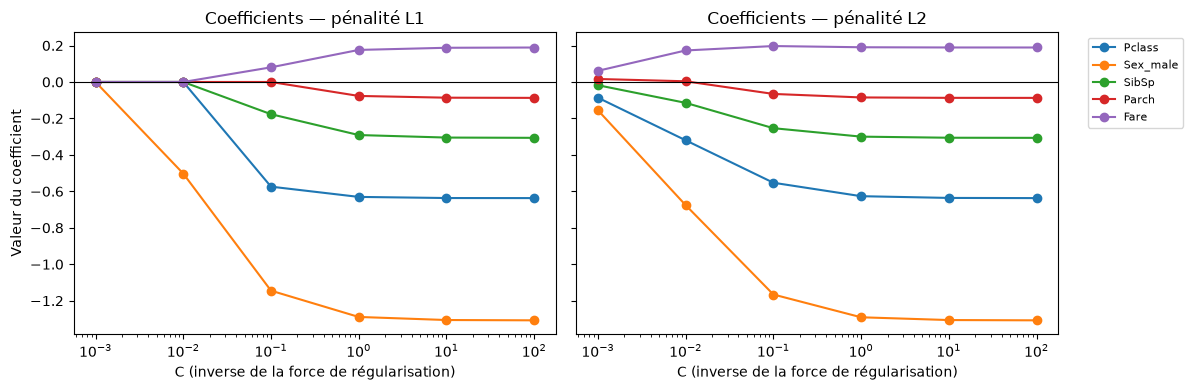

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, penalite in zip(axes, ["l1", "l2"]):
    subset = coefficients_df[coefficients_df["penalty"] == penalite]
    for feature in features:
        ax.plot(subset["C"], subset[feature], marker="o", label=feature)
    ax.set_xscale("log")
    ax.set_xlabel("C (inverse de la force de régularisation)")
    ax.set_title(f"Coefficients — pénalité {penalite.upper()}")
    ax.axhline(0, color="black", linewidth=0.8)

axes[0].set_ylabel("Valeur du coefficient")
axes[1].legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

**Ce qu'on observe** : à `C` petit (forte régularisation, à gauche des graphiques), Lasso
(L1) ramène des coefficients exactement à 0 (colonne `nb_coefficients_nuls`), alors que
Ridge (L2) les réduit sans jamais les annuler. À `C = 0.01`, Lasso ne garde que `Sex_male`,
la variable la plus discriminante, et obtient déjà 0,788 en cross-validation : c'est la
sélection de variables implicite vue en cours. À `C = 0.001`, il annule tout : le modèle ne
prédit plus que la classe majoritaire et retombe au score du modèle naïf du notebook
précédent (0,624). Une régularisation trop forte fait donc sous-apprendre.

Quand `C` augmente (régularisation plus faible), les deux méthodes convergent vers les mêmes
coefficients, ceux d'une régression logistique non régularisée.

**À retenir pour le débriefing** :

- L'**overfitting** se repère à un grand écart entre score d'entraînement et score de
  validation ; l'**underfitting** à des scores proches mais bas. Le bon compromis
  biais-variance est au sommet de la courbe de validation, pas là où le score
  d'entraînement est maximal.
- La **régularisation** limite la complexité d'un modèle : Ridge réduit les coefficients,
  Lasso peut les annuler et sélectionne ainsi des variables. Trop forte, elle fait
  sous-apprendre.
- Le réflexe est toujours le même : faire varier un hyperparamètre (profondeur, `C`, type de
  pénalité) et l'évaluer en cross-validation. `GridSearchCV` automatisera cette recherche
  au notebook 05.